In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_california_housing
from sklearn.metrics import confusion_matrix,classification_report


In [12]:
data = fetch_california_housing(as_frame=True)
df = data.frame
df.head()


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [14]:
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

In [18]:
X_train ,X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)


In [22]:
print(X_train.shape)
print(y_train.shape)

(16512, 8)
(16512,)


In [ ]:
#this is done before training the data because for NN the standard values are required
scaler = StandardScaler()
X_train = scaler.fir_transform(X_train)
X_test = scaler.fit(x_test)

In [ ]:
# model  

model = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_shape=(X_train.shape[1],)),     # here the 128 neurons will be created and learns the differnt patterns 
    tf.keras.layers.Dense(64, activation='relu'),           # here it will learn the important patterns from the above layer and reduces overfitting
    tf.keras.layers.Dense(32, activation='relu'),           # here it will learn the complex pattern only
    tf.keras.layers.Dense(1)        # output layer and in this data only one output layer
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='mse',             # checks the error value and helps in the next steps
    metrics=['mae']         # used to check the model performance
)

In [48]:
#training the model happens here 

history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6194 - mae: 0.5936 - val_loss: 0.5937 - val_mae: 0.5501
Epoch 2/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.7397 - mae: 0.6454 - val_loss: 0.6305 - val_mae: 0.5729
Epoch 3/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6322 - mae: 0.5914 - val_loss: 0.6749 - val_mae: 0.6141
Epoch 4/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6089 - mae: 0.5873 - val_loss: 0.8672 - val_mae: 0.6672
Epoch 5/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5803 - mae: 0.5725 - val_loss: 0.5401 - val_mae: 0.5591
Epoch 6/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5751 - mae: 0.5674 - val_loss: 0.5496 - val_mae: 0.5611
Epoch 7/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.5792 - mae: 0.5703 - val_loss: 0.5995 - val_mae: 0.5658
Epoch 8/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6108 - mae: 0.5881 - val_loss: 0.5725 - val_mae: 0.5914
Epoch 9/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - lo

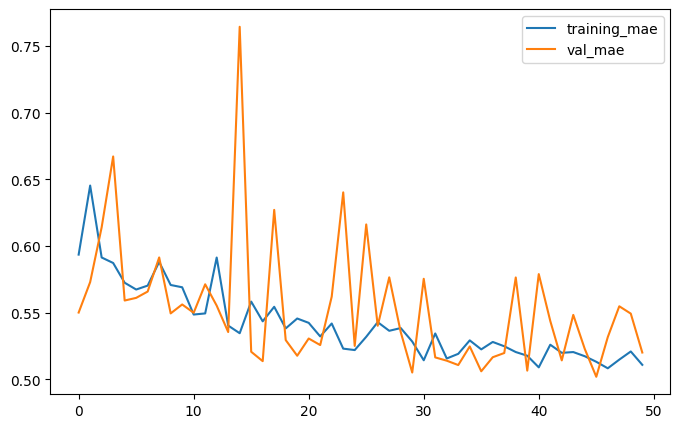

In [54]:
# checking the mae function graph ( where the training mea should high )

plt.figure(figsize=(8, 5)) 
plt.plot(history.history["mae"], label="training_mae")  
plt.plot(history.history["val_mae"], label="val_mae")       
plt.legend()
plt.show()

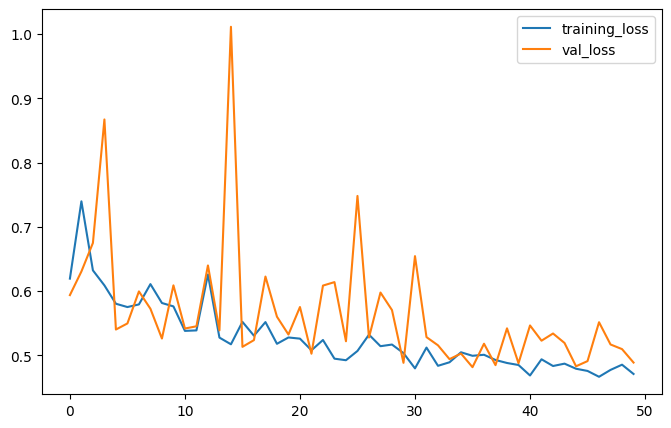

In [53]:
# checking the loss function graph ( where training_loss should be less)

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="training_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.legend()
plt.show()


In [ ]:
loss, mae = model.evaluate(X_test, y_test)
print("Test loss:", loss)  # it shows thje error of the overall model
print("Test MAE:", mae)    # it shows the average error

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5987 - mae: 0.5686
Test loss: 0.5987094044685364
Test MAE: 0.5686435699462891


In [51]:
# predicting the model that means checking the model 

predictions = model.predict(X_test)
print(predictions[:5])

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
[[0.9247136]
 [1.5872612]
 [3.8720975]
 [2.6124   ]
 [2.193293 ]]


In [35]:
# comparing the values from the model

print("Acutal value :", y_test[:10])

print("Predicted value: ", predictions[:10])

Acutal value : 20046    0.47700
3024     0.45800
15663    5.00001
20484    2.18600
9814     2.78000
13311    1.58700
7113     1.98200
7668     1.57500
18246    3.40000
5723     4.46600
Name: MedHouseVal, dtype: float64
Predicted value:  [[1.117029 ]
 [1.623071 ]
 [2.4545863]
 [2.5491977]
 [2.0559182]
 [2.258197 ]
 [2.5590646]
 [1.9878976]
 [2.1498783]
 [3.9564772]]


In [52]:
# for checking the values 

print("Mae : ", mean_absolute_error(y_test, predictions))

print("Loss : ", mean_squared_error(y_test, predictions))

Mae :  0.517003047764061
Loss :  0.48704324559775086


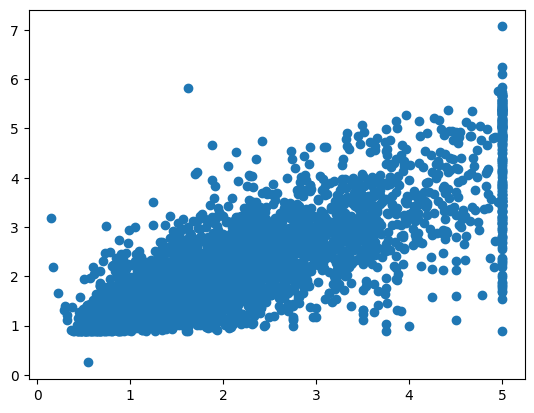

In [56]:
plt.scatter(y_test, predictions)
plt.show()